# Statistical Models and Model Quality

## Parametric Models

$$
f(x) = f(x; \beta)
$$
Where:
* \(x\) is the input variable (or vector of inputs).
* $\beta$ is the vector of parameters learned from the training data.

$$
f_l = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_p x_p
$$

We can estimate the parameters \(\beta\) using a training dataset, and then use the model to make predictions on new data.

$$
\hat{f_l} = \hat{\beta_0} + \hat{\beta_1} x_1 + \hat{\beta_2} x_2 + ... + \hat{\beta_p} x_p
$$

> [!IMPORTANT]
> *The main reason why this model does not suffer from the curse of dimensionality is that to estimate the parameter \beta and to make predictions we make use of the whole dataset, not just a local neighborhood of the input space. This means that we can learn a model that generalizes well to new data, even in high-dimensional spaces.*

Example: Linear Regression, Logistic Regression, etc.

Example when p = 1 for a polynomial regression model:
$$
f_l = \beta_0 + \beta_1 x + \beta_2 x^2 + ... + \beta_p x^p
$$

$$
\hat{f_l} = \hat{\beta_0} + \hat{\beta_1} x + \hat{\beta_2} x^2 + ... + \hat{\beta_p} x^p
$$


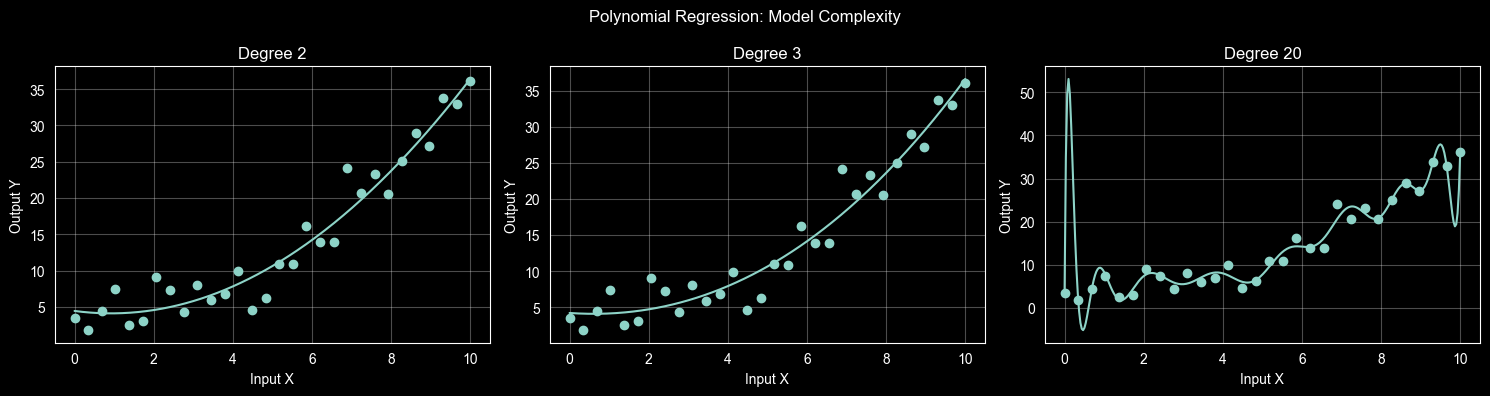

In [1]:
# Polynomial regression: degree 2, 3, and 20

import numpy as np
import matplotlib.pyplot as plt

# Data
np.random.seed(42)

X = np.linspace(0, 10, 30)
y = 2 + 0.5 * X + 0.3 * X**2 + np.random.normal(0, 3, len(X))

# Standardize X for numerical stability
X_mean = X.mean()
X_std = X.std()

X_scaled = (X - X_mean) / X_std
X_plot = np.linspace(0, 10, 300)
X_plot_scaled = (X_plot - X_mean) / X_std

degrees = [2, 3, 20]

# Three plots in one figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, degree in zip(axes, degrees):

    # Fit polynomial using standardized X
    coefficients = np.polyfit(X_scaled, y, degree)
    model = np.poly1d(coefficients)

    # Predictions
    y_plot = model(X_plot_scaled)

    # Data
    ax.scatter(X, y)

    # Polynomial regression
    ax.plot(X_plot, y_plot)

    ax.set_title(f"Degree {degree}")
    ax.set_xlabel("Input X")
    ax.set_ylabel("Output Y")
    ax.grid(alpha=0.3)

plt.suptitle("Polynomial Regression: Model Complexity")
plt.tight_layout()
plt.show()

## Model Quality: Training vs. Test Error

When evaluating a machine learning model, we want to know **how well it will perform on new, unseen data**, not just how well it fits the data it was trained on.

### 1. Training Dataset

The **training dataset** is the data used to estimate the model parameters.

$$
D_{Tr} = \{(X_i,Y_i)\}_{i=1}^{N}
$$

The model learns its parameters $\theta$ using this data.

### Training MSE

The **training mean squared error (MSE)** measures how well the model fits the training data:

$$
\boxed{
MSE_{train}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left(Y_i-\hat f(X_i)\right)^2
}
$$

* $Y_i$ = actual output
* $\hat f(X_i)$ = model's prediction
* $N$ = number of training observations

---

## 2. Testing Dataset

The **testing dataset** contains data that the model **has not seen during training**.

$$
D_{Te} = \{(X_i,Y_i)\}_{i=1}^{M}
$$

We use it to estimate how well the model will perform on **future/unseen observations**.

### Test MSE

$$
\boxed{
MSE_{test}
=
\frac{1}{M}
\sum_{i=1}^{M}
\left(Y_i-\hat f(X_i)\right)^2
}
$$

The test MSE is generally a better measure of **generalization performance** than training MSE.

---

# 3. Training MSE vs. Test MSE

As model flexibility increases:

### Training MSE

Training MSE generally **decreases** as model flexibility increases.

Why?

> A more flexible model can fit the training data more closely.

So:

$$
\text{More flexibility}
\quad\Rightarrow\quad
\text{Lower training MSE}
$$

However, a low training MSE does **not necessarily mean** the model is good.

---

### Test MSE

Test MSE typically follows a **U-shaped curve**:

$$
\text{Test MSE}
\downarrow
\quad\rightarrow\quad
\boxed{\text{minimum}}
\quad\rightarrow\quad
\uparrow
$$

There is an **optimal level of model flexibility** where test MSE is minimized.

This is the flexibility we would like to choose because our goal is good performance on unseen data.

---

# 4. Underfitting and Overfitting

### Underfitting

When the model is **not flexible enough**:

$$
\text{Low flexibility}
\rightarrow
\text{Underfitting}
$$

The model is too simple to capture the underlying regression function.

Characteristics:

* High training MSE
* High test MSE
* Model fails to capture important patterns

---

### Overfitting

When the model is **too flexible**:

$$
\text{High flexibility}
\rightarrow
\text{Overfitting}
$$

The model begins fitting the **noise** in the training data rather than the underlying relationship.

Characteristics:

* Very low training MSE
* High test MSE
* Poor performance on unseen data

Example:

A polynomial with degree $20$ may wiggle through the training points instead of learning the underlying trend.

---

# 5. Optimal Model Complexity

The goal is **not** to minimize training MSE.

Instead, we want to choose the model complexity that minimizes **test error**.

$$
\boxed{
\text{Choose complexity that minimizes test MSE}
}
$$

Conceptually:

$$
\text{Underfitting}
\quad\longrightarrow\quad
\boxed{\text{Optimal}}
\quad\longrightarrow\quad
\text{Overfitting}
$$

### Key Idea

> **Training error tells us how well the model fits the data it has seen. Test error tells us how well the model generalizes to unseen data.**

---

## Polynomial Example

For polynomial regression:

| Degree | Flexibility | Typical behavior         |
| ------ | ----------- | ------------------------ |
| $d=1$  | Low         | May underfit             |
| $d=2$  | Moderate    | Better fit               |
| $d=3$  | Moderate    | May have lowest test MSE |
| $d=20$ | Very high   | Likely overfits          |

Importantly:

$$
MSE_{train} \downarrow
\quad\text{as}\quad d\uparrow
$$

but

$$
MSE_{test}
$$

may first decrease and then increase.

Therefore, **the model with the lowest training MSE is not necessarily the best model.**


## Bias-Variance Tradeoff

The **test MSE** can be theoretically decomposed into three parts:

$$
\boxed{
\text{Test MSE}
=
\text{Bias}^2
+
\text{Variance}
+
\text{Irreducible Error}
}
$$

This explains why the test MSE typically has a **U-shaped curve** as model flexibility increases.

---

## 1. Test MSE

For a new, unseen observation $(X_0,Y_0)$:

$$
\boxed{
\text{Test MSE}
=
E\left[
(Y_0-\hat f(X_0))^2
\right]
}
$$

The expectation is used because the new observation is random.

Using the additive model:

$$
Y_0=f(X_0)+\epsilon
$$

the test MSE can be decomposed as:

$$
\boxed{
E[(Y_0-\hat f(X_0))^2]
=
\underbrace{
\left(E[\hat f(X_0)]-f(X_0)\right)^2
}_{\text{Bias}^2}
+
\underbrace{
Var(\hat f(X_0))
}_{\text{Variance}}
+
\underbrace{
Var(\epsilon)
}_{\text{Irreducible Error}}
}
$$

---

# 2. Bias

**Bias measures how far the average prediction of our model is from the true regression function.**

$$
\boxed{
Bias^2 =
\left(E[\hat f(X_0)]-f(X_0)\right)^2
}
$$

Think of it as:

> **Is my model systematically wrong?**

A model with **high bias** is usually too simple and cannot capture the underlying pattern.

### As flexibility increases:

$$
\boxed{
\text{Flexibility}\uparrow
\quad\Rightarrow\quad
\text{Bias}\downarrow
}
$$

Example:

A linear model trying to fit a curved relationship may have high bias.

---

# 3. Variance

**Variance measures how much the model's prediction changes when the training dataset changes.**

$$
\boxed{
Variance =
Var(\hat f(X_0))
}
$$

Think of it as:

> **If I trained my model on a different sample of data, would I get a very different prediction?**

A highly flexible model can react strongly to small changes in the training data.

### As flexibility increases:

$$
\boxed{
\text{Flexibility}\uparrow
\quad\Rightarrow\quad
\text{Variance}\uparrow
}
$$

---

# 4. Irreducible Error

The final component is:

$$
\boxed{
Var(\epsilon)
}
$$

This is the **noise inherent in the data**.

It cannot be eliminated by choosing a better model.

Even if:

$$
\hat f(x)=f(x)
$$

perfectly, we still have:

$$
Y=f(X)+\epsilon
$$

Therefore:

$$
\boxed{
\text{Irreducible Error}=Var(\epsilon)
}
$$

### Important:

* Does **not** depend on model flexibility.
* Cannot be reduced by improving the model.
* Comes from noise/randomness in the data.

---

# 5. Reducible vs. Irreducible Error

The first two terms are called **reducible error**:

$$
\boxed{
\text{Reducible Error}
=
Bias^2+Variance
}
$$

They depend on the model we choose.

The last term is **irreducible error**:

$$
\boxed{
\text{Irreducible Error}
=
Var(\epsilon)
}
$$

Therefore:

$$
\boxed{
\text{Test MSE}
=
\underbrace{Bias^2+Variance}_{\text{Reducible}}
+
\underbrace{Var(\epsilon)}_{\text{Irreducible}}
}
$$

---

# 6. Bias–Variance Tradeoff

The key problem is that **bias and variance move in opposite directions** as model flexibility increases.

| Model flexibility |     Bias | Variance |
| ----------------- | -------: | -------: |
| Low               |     High |      Low |
| Medium            |      Low |      Low |
| High              | Very low |     High |

Therefore:

$$
\text{Flexibility}\uparrow
\Rightarrow
\begin{cases}
Bias\downarrow\\
Variance\uparrow
\end{cases}
$$

The goal is to find the **optimal level of flexibility** that minimizes:

$$
Bias^2+Variance
$$

and therefore minimizes test MSE.

---

# 7. Polynomial Example

Consider polynomial models with degrees:

$$
d=1,\quad d=3,\quad d=20
$$

### Degree 1 — Linear

Low flexibility:

$$
\boxed{\text{High Bias + Low Variance}}
$$

The model is too rigid and cannot adapt much to different training datasets.

This is an example of **underfitting**.

---

### Degree 3 — Cubic

Moderate flexibility:

$$
\boxed{\text{Low Bias + Low Variance}}
$$

The model captures the underlying relationship without being overly sensitive to the particular training sample.

This represents a good balance.

---

### Degree 20

Very high flexibility:

$$
\boxed{\text{Low Bias + High Variance}}
$$

The model can closely follow the training data, including random noise.

This is **overfitting**.

---

# 8. The Big Picture

As flexibility increases:

$$
\boxed{
Bias^2\downarrow
\qquad
Variance\uparrow
}
$$

while:

$$
\boxed{
\text{Irreducible Error}=\text{constant}
}
$$

Therefore, test MSE behaves approximately like:

$$
\boxed{
\text{Test MSE}
=
\underbrace{Bias^2}_{\downarrow}
+
\underbrace{Variance}_{\uparrow}
+
\underbrace{Irreducible Error}_{\text{constant}}
}
$$

This produces the familiar **U-shaped test MSE curve**.

### Main goal

> **Choose the model complexity where the total test MSE is minimized.**

---

## What to Remember

The entire concept can be summarized in one diagram:

$$
\boxed{
\text{Too Simple}
\rightarrow
\text{Optimal}
\rightarrow
\text{Too Complex}
}
$$

$$
\boxed{
\text{High Bias}
\rightarrow
\text{Low Bias}
\rightarrow
\text{Low Bias}
}
$$

$$
\boxed{
\text{Low Variance}
\rightarrow
\text{Low Variance}
\rightarrow
\text{High Variance}
}
$$

And the most important formula:

$$
\boxed{
\text{Test MSE}
=
Bias^2+Variance+\text{Irreducible Error}
}
$$

### Connection to the previous section

**Underfitting** → high bias → model not flexible enough

**Optimal model** → good bias/variance balance

**Overfitting** → high variance → model too flexible


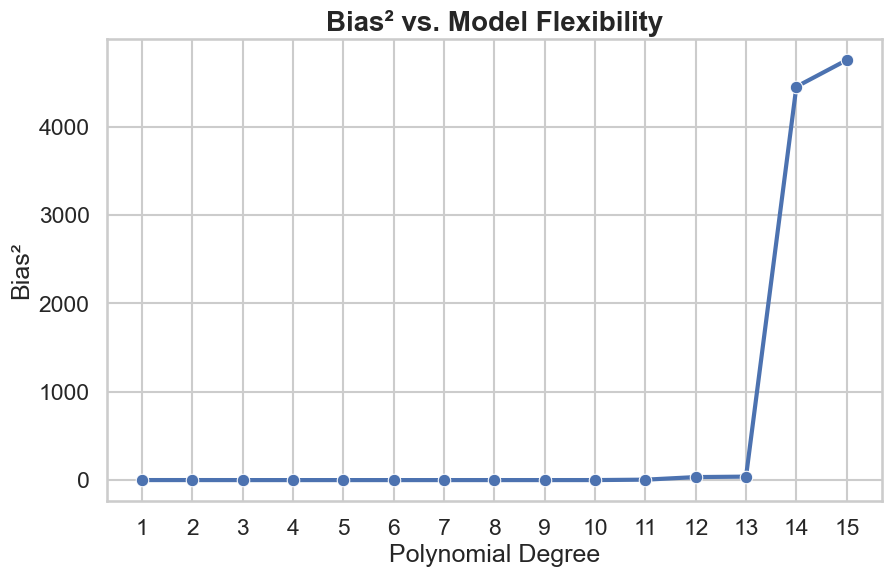

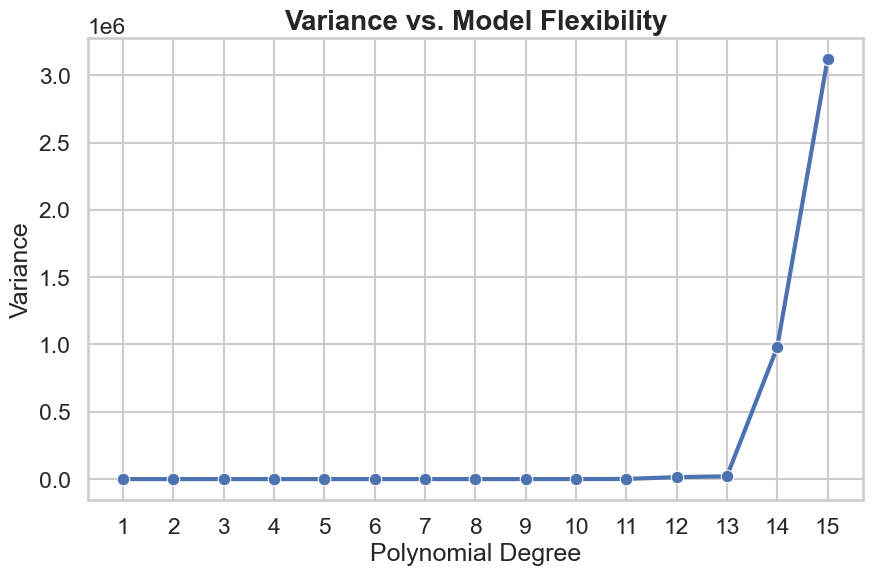

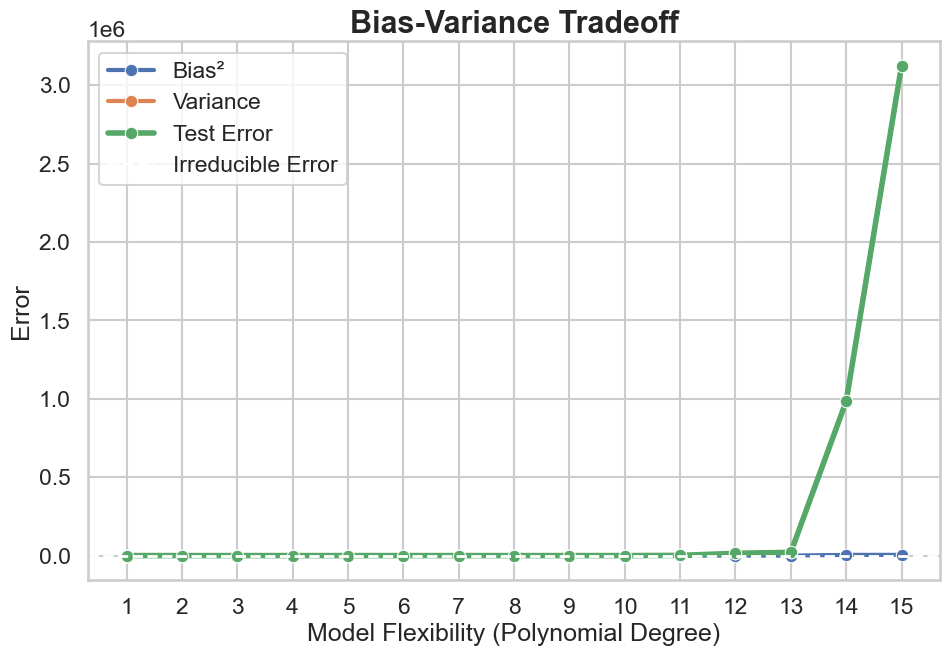

Optimal polynomial degree: 3
Minimum test error: 0.0522


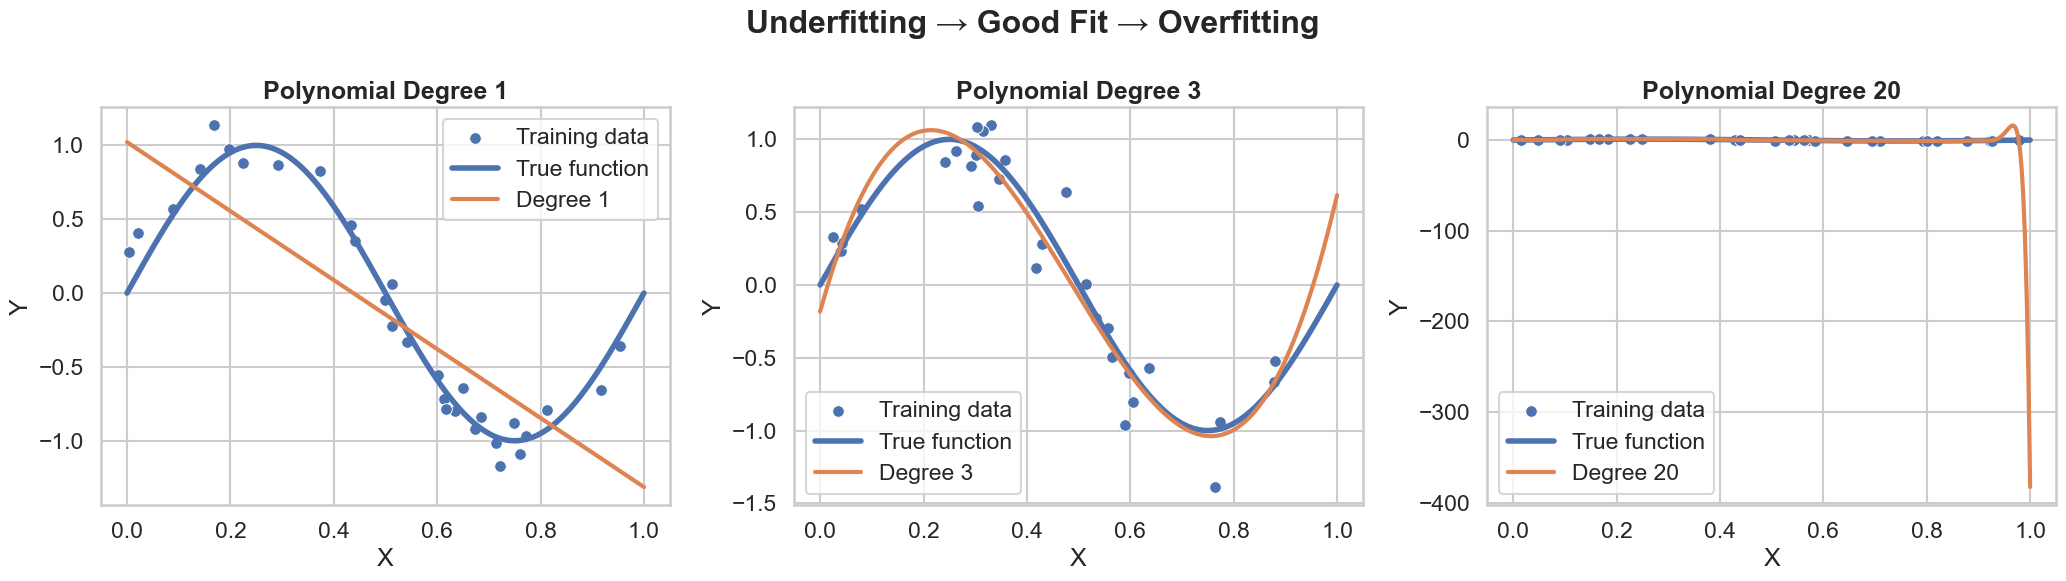

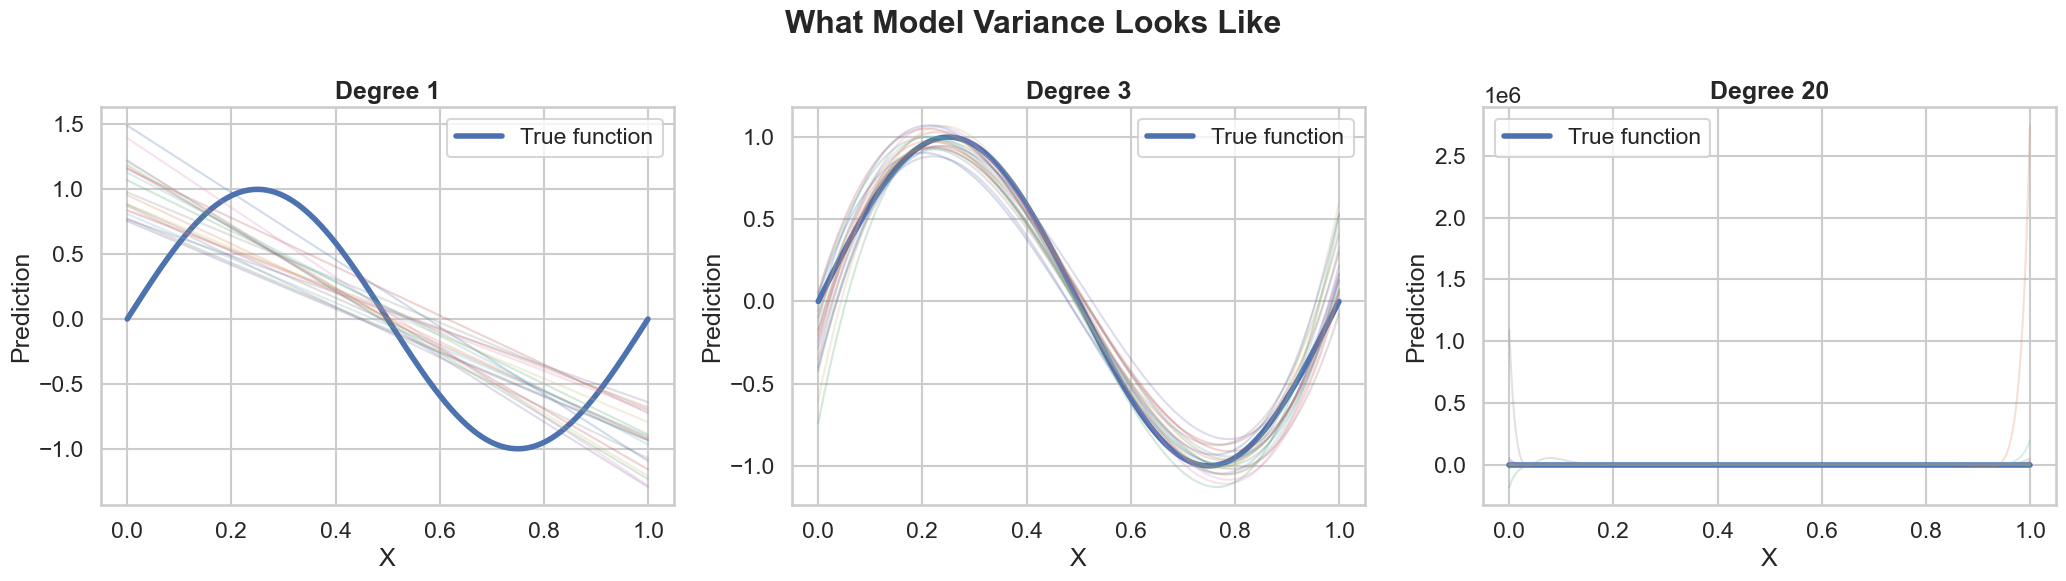

In [2]:
# ============================================================
# BIAS-VARIANCE TRADEOFF
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Nice Seaborn style
sns.set_theme(
    style="whitegrid",
    context="talk"
)

# Reproducibility
np.random.seed(42)


# ============================================================
# 1. TRUE REGRESSION FUNCTION
# ============================================================

def f_true(x):
    return np.sin(2 * np.pi * x)


# ============================================================
# 2. SETTINGS
# ============================================================

n_train = 30
n_datasets = 200
noise_std = 0.20

# Polynomial degrees
degrees = np.arange(1, 16)

# Test points
x_test = np.linspace(0, 1, 300)

# True function values
y_true = f_true(x_test)


# ============================================================
# 3. TRAIN MANY MODELS
# ============================================================
# We train each polynomial on 200 DIFFERENT datasets.
#
# Why?
# To measure VARIANCE, we need to see how much the
# model changes when the training data changes.
# ============================================================

all_predictions = {
    d: [] for d in degrees
}

for _ in range(n_datasets):

    # Generate training data
    X_train = np.random.uniform(
        0,
        1,
        n_train
    )

    y_train = (
        f_true(X_train)
        + np.random.normal(
            0,
            noise_std,
            n_train
        )
    )

    for d in degrees:

        # ====================================================
        # FIX:
        # Polynomial.fit is more numerically stable than
        # np.polyfit for high-degree polynomials.
        # ====================================================

        model = np.polynomial.Polynomial.fit(
            X_train,
            y_train,
            d
        )

        # Predict
        y_pred = model(x_test)

        # Save predictions
        all_predictions[d].append(y_pred)


# ============================================================
# 4. CALCULATE BIAS², VARIANCE, AND TEST ERROR
# ============================================================

bias_squared = []
variance = []
test_error = []

# Irreducible error
irreducible_error = noise_std ** 2


for d in degrees:

    # Convert predictions to NumPy array
    #
    # Shape:
    # 200 datasets × 300 test points
    predictions = np.array(
        all_predictions[d]
    )

    # --------------------------------------------------------
    # Average prediction across all 200 models
    # --------------------------------------------------------

    mean_prediction = np.mean(
        predictions,
        axis=0
    )

    # --------------------------------------------------------
    # BIAS²
    #
    # How far is the average prediction from
    # the true regression function?
    # --------------------------------------------------------

    bias = np.mean(
        (mean_prediction - y_true) ** 2
    )

    # --------------------------------------------------------
    # VARIANCE
    #
    # How much do predictions change across
    # different training datasets?
    # --------------------------------------------------------

    var = np.mean(
        np.var(
            predictions,
            axis=0
        )
    )

    # --------------------------------------------------------
    # TOTAL TEST ERROR
    #
    # Test MSE = Bias² + Variance + Irreducible Error
    # --------------------------------------------------------

    error = (
        bias
        + var
        + irreducible_error
    )

    # Store results
    bias_squared.append(bias)
    variance.append(var)
    test_error.append(error)


# ============================================================
# 5. PLOT BIAS²
# ============================================================

plt.figure(figsize=(10, 6))

sns.lineplot(
    x=degrees,
    y=bias_squared,
    marker="o",
    linewidth=3
)

plt.title(
    "Bias² vs. Model Flexibility",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel(
    "Polynomial Degree"
)

plt.ylabel(
    "Bias²"
)

plt.xticks(degrees)

plt.show()


# ============================================================
# 6. PLOT VARIANCE
# ============================================================

plt.figure(figsize=(10, 6))

sns.lineplot(
    x=degrees,
    y=variance,
    marker="o",
    linewidth=3
)

plt.title(
    "Variance vs. Model Flexibility",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel(
    "Polynomial Degree"
)

plt.ylabel(
    "Variance"
)

plt.xticks(degrees)

plt.show()


# ============================================================
# 7. BIAS-VARIANCE TRADEOFF
# ============================================================

plt.figure(figsize=(11, 7))

sns.lineplot(
    x=degrees,
    y=bias_squared,
    marker="o",
    linewidth=3,
    label="Bias²"
)

sns.lineplot(
    x=degrees,
    y=variance,
    marker="o",
    linewidth=3,
    label="Variance"
)

sns.lineplot(
    x=degrees,
    y=test_error,
    marker="o",
    linewidth=4,
    label="Test Error"
)

# Irreducible error
plt.axhline(
    irreducible_error,
    linestyle="--",
    linewidth=2,
    label="Irreducible Error"
)

plt.title(
    "Bias-Variance Tradeoff",
    fontsize=22,
    fontweight="bold"
)

plt.xlabel(
    "Model Flexibility (Polynomial Degree)"
)

plt.ylabel(
    "Error"
)

plt.xticks(degrees)

plt.legend()

plt.show()


# ============================================================
# 8. FIND OPTIMAL DEGREE
# ============================================================

optimal_degree = degrees[
    np.argmin(test_error)
]

print(
    f"Optimal polynomial degree: {optimal_degree}"
)

print(
    f"Minimum test error: "
    f"{min(test_error):.4f}"
)


# ============================================================
# 9. d = 1, 3, 20
# ============================================================

np.random.seed(10)

degrees_to_plot = [1, 3, 20]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 6)
)


for ax, d in zip(
    axes,
    degrees_to_plot
):

    # --------------------------------------------------------
    # Generate ONE training dataset
    # --------------------------------------------------------

    X_train = np.random.uniform(
        0,
        1,
        n_train
    )

    y_train = (
        f_true(X_train)
        + np.random.normal(
            0,
            noise_std,
            n_train
        )
    )

    # --------------------------------------------------------
    # Fit polynomial
    # --------------------------------------------------------

    model = np.polynomial.Polynomial.fit(
        X_train,
        y_train,
        d
    )

    # Predictions
    y_pred = model(x_test)

    # --------------------------------------------------------
    # Training data
    # --------------------------------------------------------

    sns.scatterplot(
        x=X_train,
        y=y_train,
        ax=ax,
        s=70,
        label="Training data"
    )

    # --------------------------------------------------------
    # True regression function
    # --------------------------------------------------------

    sns.lineplot(
        x=x_test,
        y=y_true,
        ax=ax,
        linewidth=4,
        label="True function"
    )

    # --------------------------------------------------------
    # Polynomial model
    # --------------------------------------------------------

    sns.lineplot(
        x=x_test,
        y=y_pred,
        ax=ax,
        linewidth=3,
        label=f"Degree {d}"
    )

    ax.set_title(
        f"Polynomial Degree {d}",
        fontsize=18,
        fontweight="bold"
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Y")


plt.suptitle(
    "Underfitting → Good Fit → Overfitting",
    fontsize=23,
    fontweight="bold"
)

plt.tight_layout()

plt.show()


# ============================================================
# 10. VISUALIZE VARIANCE
# ============================================================
# Each line = model trained on a DIFFERENT dataset.
#
# d = 1  → lines stay close together → LOW VARIANCE
# d = 3  → lines stay relatively close → LOW VARIANCE
# d = 20 → lines jump around → HIGH VARIANCE
# ============================================================

np.random.seed(100)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(21, 6)
)


for ax, d in zip(
    axes,
    degrees_to_plot
):

    # --------------------------------------------------------
    # True function
    # --------------------------------------------------------

    sns.lineplot(
        x=x_test,
        y=y_true,
        ax=ax,
        linewidth=4,
        label="True function"
    )

    # --------------------------------------------------------
    # Train 20 different models
    # --------------------------------------------------------

    for i in range(20):

        X_train = np.random.uniform(
            0,
            1,
            n_train
        )

        y_train = (
            f_true(X_train)
            + np.random.normal(
                0,
                noise_std,
                n_train
            )
        )

        # Stable polynomial fitting
        model = np.polynomial.Polynomial.fit(
            X_train,
            y_train,
            d
        )

        # Prediction
        y_pred = model(x_test)

        # Plot model
        sns.lineplot(
            x=x_test,
            y=y_pred,
            ax=ax,
            alpha=0.25,
            linewidth=1.5
        )

    ax.set_title(
        f"Degree {d}",
        fontsize=18,
        fontweight="bold"
    )

    ax.set_xlabel("X")
    ax.set_ylabel("Prediction")


plt.suptitle(
    "What Model Variance Looks Like",
    fontsize=23,
    fontweight="bold"
)

plt.tight_layout()

plt.show()